# Introduction to 3-DOF Rocket Simulations with RocketPy

This notebook demonstrates the use of 3-DOF (3 Degrees of Freedom) trajectory simulations using RocketPy's `PointMassRocket` class.

## What is 3-DOF simulation?

In a 3-DOF simulation:
- The rocket is modeled as a **point mass** (no rotational dynamics)
- Only **translational motion** is simulated (x, y, z position and velocity)
- **No attitude dynamics** (pitch, yaw, roll) are computed
- Significantly **faster computation** compared to 6-DOF
- Useful for quick trajectory analysis and Monte Carlo studies

## When to use 3-DOF?

3-DOF simulations are appropriate when:
- Rotational dynamics are not critical to the analysis
- You need fast computation for many simulations (e.g., Monte Carlo)
- You're doing preliminary design or sensitivity studies
- Educational purposes or simplified models

## Getting Started

In [1]:
# Import required libraries
from rocketpy import Environment
from rocketpy.motors.point_mass_motor import PointMassMotor
from rocketpy.rocket.point_mass_rocket import PointMassRocket
from rocketpy.simulation.flight import Flight
import matplotlib.pyplot as plt
import numpy as np

## Step 1: Define the Environment

Just like in 6-DOF simulations, we start by defining the launch environment.

In [2]:
# Create a simple environment
# Location: approximate coordinates for a launch site
env = Environment(
    latitude=39.389,
    longitude=-8.289,
    elevation=113  # meters above sea level
)

# Set atmospheric model to standard atmosphere (simple and fast)
env.set_atmospheric_model(type='standard_atmosphere')

print(f"Environment created at latitude {env.latitude}°, longitude {env.longitude}°")
print(f"Elevation: {env.elevation} m")

Environment created at latitude 39.389°, longitude -8.289°
Elevation: 113 m


## Step 2: Create a Point Mass Motor

For 3-DOF simulations, we use the `PointMassMotor` class which provides a simplified motor model.

Key parameters:
- `thrust_source`: Constant thrust (N) or thrust curve file
- `dry_mass`: Motor dry mass (kg)
- `propellant_initial_mass`: Initial propellant mass (kg)
- `burn_time`: Total burn duration (s)

In [3]:
# Create a simple point mass motor
# This represents a small solid motor
motor = PointMassMotor(
    thrust_source=500,  # 500 N constant thrust
    dry_mass=1.5,       # 1.5 kg dry mass
    propellant_initial_mass=2.0,  # 2.0 kg propellant
    burn_time=3.5,      # 3.5 seconds burn time
)

print(f"Motor total impulse: {motor.total_impulse:.2f} N·s")
print(f"Motor dry mass: {motor.dry_mass:.2f} kg")
print(f"Motor burn time: {motor.burn_time[1]:.2f} s")

Motor total impulse: 1750.00 N·s
Motor dry mass: 1.50 kg
Motor burn time: 3.50 s


## Step 3: Create a Point Mass Rocket

The `PointMassRocket` is a simplified rocket model for 3-DOF simulations.

Key parameters:
- `radius`: Rocket reference radius (m)
- `mass`: Dry mass without motor (kg)
- `center_of_mass_without_motor`: CM position (m)
- `power_off_drag`: Drag coefficient when motor is off
- `power_on_drag`: Drag coefficient when motor is on

In [4]:
# Create a simple point mass rocket
rocket = PointMassRocket(
    radius=0.0635,  # 63.5 mm radius (127 mm diameter)
    mass=5.0,       # 5 kg dry mass (without motor)
    center_of_mass_without_motor=0.0,  # at coordinate system origin
    power_off_drag=0.5,   # drag coefficient when motor is off
    power_on_drag=0.5,    # drag coefficient when motor is on
)

# Add the motor to the rocket
rocket.add_motor(motor, position=0.0)

print(f"Rocket dry mass: {rocket.mass:.2f} kg")
print(f"Total mass at liftoff: {rocket.mass + motor.propellant_initial_mass + motor.dry_mass:.2f} kg")
print(f"Rocket radius: {rocket.radius:.4f} m")

Rocket dry mass: 5.00 kg
Total mass at liftoff: 8.50 kg
Rocket radius: 0.0635 m


## Step 4: Run a 3-DOF Flight Simulation

Now we create a `Flight` object with `simulation_mode='3 DOF'`.

**Important**: When using a `PointMassRocket`, RocketPy automatically sets the simulation to 3-DOF mode.

In [5]:
# Create and run the flight simulation
flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=5.0,        # 5 m launch rail
    inclination=84,         # 84° from horizontal (nearly vertical)
    heading=90,             # 90° heading (East)
    simulation_mode='3 DOF', # Explicitly set 3-DOF mode
    max_time=100,           # Maximum simulation time (s)
)

print(f"\nSimulation mode: {flight.simulation_mode}")
# print(f"Simulation completed in {flight.total_cpu_time:.4f} seconds")  # Note: total_cpu_time not available on Flight object


Simulation mode: 3 DOF


## Step 5: Analyze Results

Let's examine the key flight characteristics.

In [6]:
# Display key flight metrics
print("=" * 50)
print("FLIGHT RESULTS")
print("=" * 50)
print(f"Apogee altitude: {flight.apogee - env.elevation:.2f} m AGL")
print(f"Apogee time: {flight.apogee_time:.2f} s")
print(f"Maximum speed: {flight.max_speed:.2f} m/s")
print(f"Maximum acceleration: {flight.max_acceleration:.2f} m/s²")
print(f"Impact velocity: {flight.impact_velocity:.2f} m/s")
print(f"Impact position (x): {flight.x_impact:.2f} m")
print(f"Impact position (y): {flight.y_impact:.2f} m")
print(f"Total flight time: {flight.t_final:.2f} s")

FLIGHT RESULTS
Apogee altitude: 1235.70 m AGL
Apogee time: 16.03 s
Maximum speed: 230.41 m/s
Maximum acceleration: 52.80 m/s²
Impact velocity: -230.33 m/s
Impact position (x): 453.01 m
Impact position (y): 0.00 m
Total flight time: 30.11 s


## Step 6: Visualize Trajectory

Let's plot the rocket's trajectory.

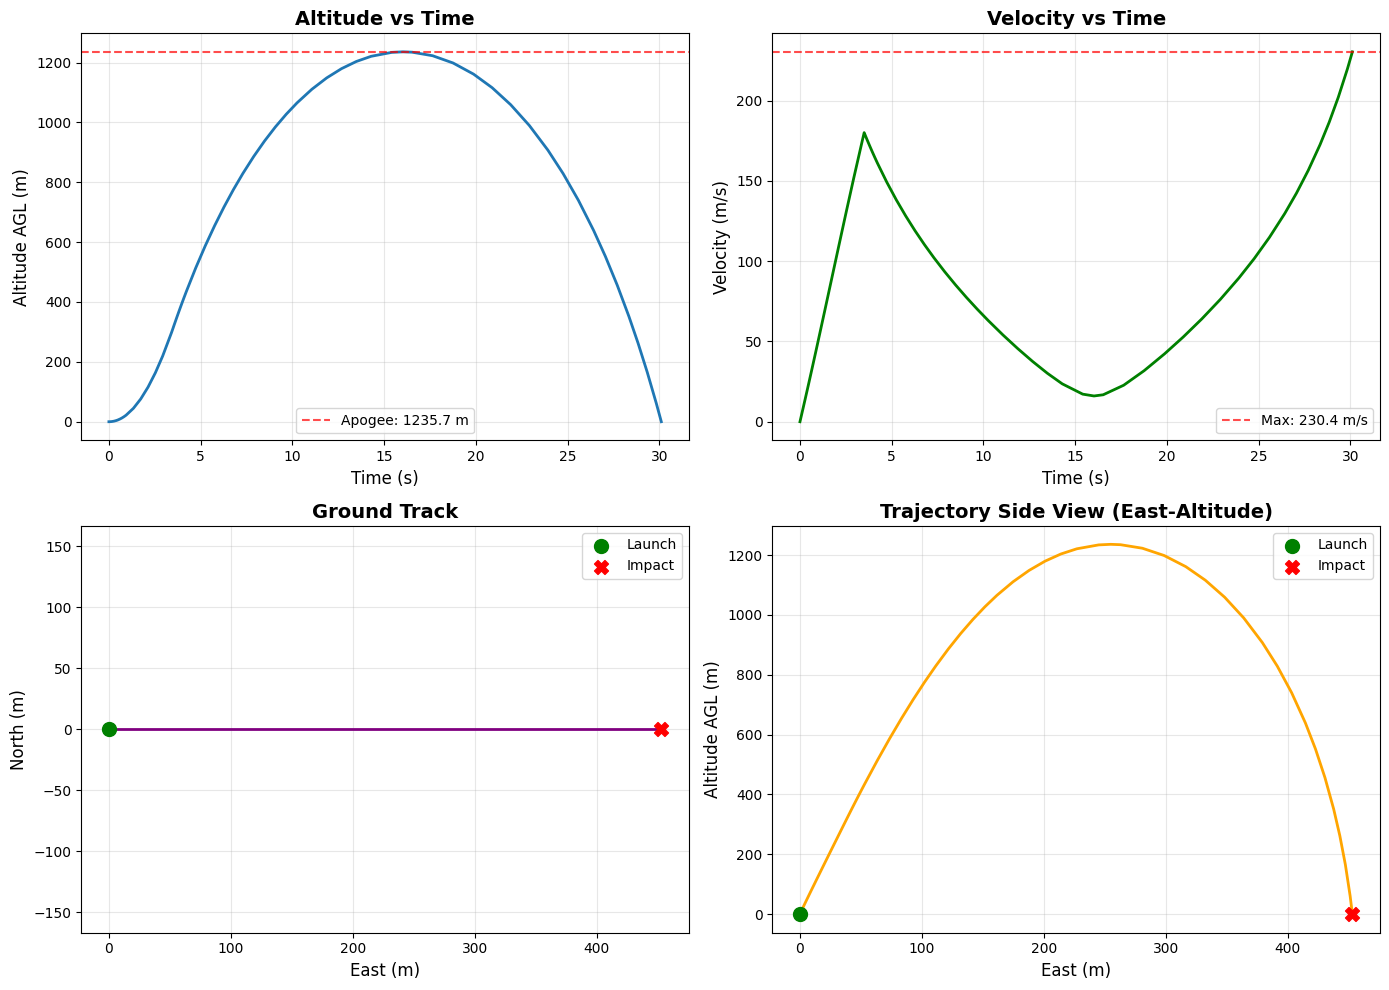


Trajectory plots saved as '3dof_basic_trajectory.png'


In [7]:
# Create trajectory plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Altitude vs time
time = np.array(flight.z.source)[:, 0]
altitude = np.array(flight.z.source)[:, 1] - env.elevation
axes[0, 0].plot(time, altitude, linewidth=2)
axes[0, 0].set_xlabel('Time (s)', fontsize=12)
axes[0, 0].set_ylabel('Altitude AGL (m)', fontsize=12)
axes[0, 0].set_title('Altitude vs Time', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=flight.apogee - env.elevation, color='r', linestyle='--', alpha=0.7, label=f'Apogee: {flight.apogee - env.elevation:.1f} m')
axes[0, 0].legend()

# Velocity vs time
velocity = np.sqrt(np.array(flight.vx.source)[:, 1]**2 + 
                   np.array(flight.vy.source)[:, 1]**2 + 
                   np.array(flight.vz.source)[:, 1]**2)
axes[0, 1].plot(time, velocity, linewidth=2, color='green')
axes[0, 1].set_xlabel('Time (s)', fontsize=12)
axes[0, 1].set_ylabel('Velocity (m/s)', fontsize=12)
axes[0, 1].set_title('Velocity vs Time', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=flight.max_speed, color='r', linestyle='--', alpha=0.7, label=f'Max: {flight.max_speed:.1f} m/s')
axes[0, 1].legend()

# Ground track (x-y plot)
x_pos = np.array(flight.x.source)[:, 1]
y_pos = np.array(flight.y.source)[:, 1]
axes[1, 0].plot(x_pos, y_pos, linewidth=2, color='purple')
axes[1, 0].scatter([0], [0], color='green', s=100, marker='o', label='Launch', zorder=5)
axes[1, 0].scatter([flight.x_impact], [flight.y_impact], color='red', s=100, marker='X', label='Impact', zorder=5)
axes[1, 0].set_xlabel('East (m)', fontsize=12)
axes[1, 0].set_ylabel('North (m)', fontsize=12)
axes[1, 0].set_title('Ground Track', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].axis('equal')

# 3D trajectory projection
axes[1, 1].plot(x_pos, altitude, linewidth=2, color='orange')
axes[1, 1].scatter([0], [0], color='green', s=100, marker='o', label='Launch', zorder=5)
axes[1, 1].scatter([flight.x_impact], [0], color='red', s=100, marker='X', label='Impact', zorder=5)
axes[1, 1].set_xlabel('East (m)', fontsize=12)
axes[1, 1].set_ylabel('Altitude AGL (m)', fontsize=12)
axes[1, 1].set_title('Trajectory Side View (East-Altitude)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('3dof_basic_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTrajectory plots saved as '3dof_basic_trajectory.png'")

## Step 7: Parameter Sensitivity

Let's see how changing launch parameters affects the trajectory.
This demonstrates the speed advantage of 3-DOF for quick studies.

Testing different launch inclinations...
  Inclination 70°: Apogee = 1071.8 m, Range = 1282.4 m
  Inclination 75°: Apogee = 1146.6 m, Range = 1034.4 m
  Inclination 80°: Apogee = 1204.5 m, Range = 730.9 m
  Inclination 84°: Apogee = 1235.7 m, Range = 453.0 m
  Inclination 88°: Apogee = 1251.8 m, Range = 153.6 m
  Inclination 90°: Apogee = 1253.8 m, Range = 0.0 m


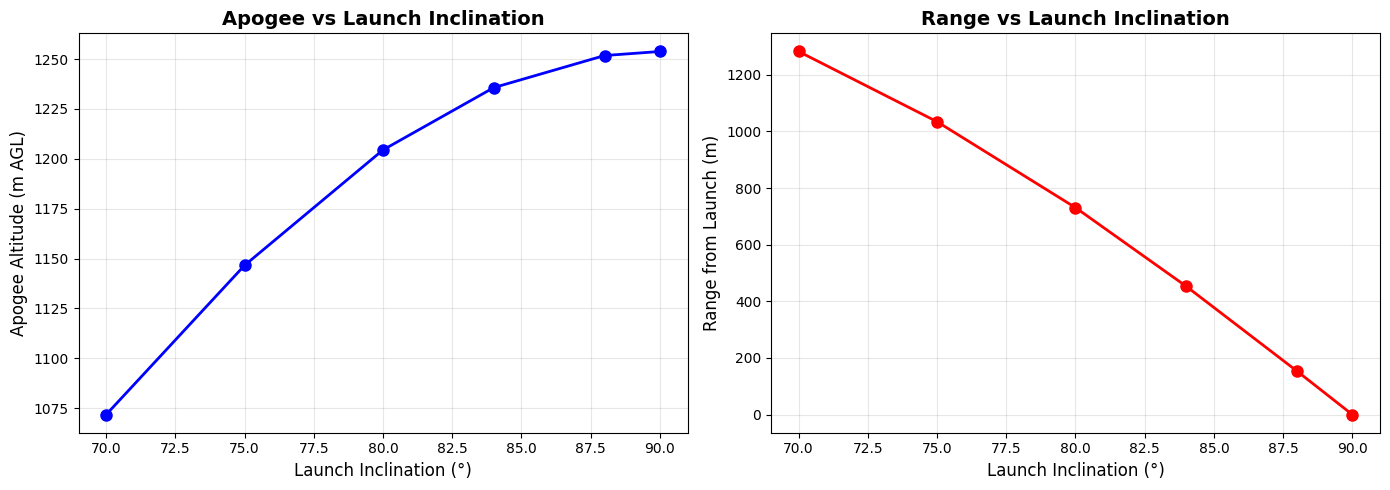


Sensitivity analysis plots saved as '3dof_sensitivity_analysis.png'


In [8]:
# Test different inclination angles
inclinations = [70, 75, 80, 84, 88, 90]
apogees = []
ranges = []

print("Testing different launch inclinations...")
for inc in inclinations:
    test_flight = Flight(
        rocket=rocket,
        environment=env,
        rail_length=5.0,
        inclination=inc,
        heading=90,
        simulation_mode='3 DOF',
        max_time=100,
        verbose=False
    )
    apogees.append(test_flight.apogee - env.elevation)
    ranges.append(np.sqrt(test_flight.x_impact**2 + test_flight.y_impact**2))
    print(f"  Inclination {inc}°: Apogee = {test_flight.apogee - env.elevation:.1f} m, Range = {ranges[-1]:.1f} m")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(inclinations, apogees, 'o-', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Launch Inclination (°)', fontsize=12)
ax1.set_ylabel('Apogee Altitude (m AGL)', fontsize=12)
ax1.set_title('Apogee vs Launch Inclination', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(inclinations, ranges, 'o-', linewidth=2, markersize=8, color='red')
ax2.set_xlabel('Launch Inclination (°)', fontsize=12)
ax2.set_ylabel('Range from Launch (m)', fontsize=12)
ax2.set_title('Range vs Launch Inclination', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3dof_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSensitivity analysis plots saved as '3dof_sensitivity_analysis.png'")

## Conclusion

This notebook introduced 3-DOF rocket trajectory simulations using RocketPy:

✅ Created a `PointMassMotor` for simplified propulsion modeling  
✅ Built a `PointMassRocket` for 3-DOF simulations  
✅ Ran fast trajectory simulations without rotational dynamics  
✅ Analyzed flight results and visualized trajectories  
✅ Performed parameter sensitivity studies  

### Next Steps

- **Monte Carlo Analysis**: See the next notebook for using 3-DOF with Monte Carlo simulations
- **Advanced Use Cases**: Explore wind effects, different motor profiles, and optimization
- **Comparison with 6-DOF**: Understand when to use each simulation mode

### Key Advantages of 3-DOF

- **Speed**: 5-10x faster than 6-DOF simulations
- **Simplicity**: Easier to set up and understand
- **Monte Carlo**: Ideal for running thousands of simulations
- **Preliminary Design**: Quick trajectory estimates

### Limitations

- No attitude/orientation tracking
- No rotational stability analysis
- No spin dynamics
- Simplified aerodynamic model